In [2]:
import os
import time
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
# 2. Load training text

with open("data/training_text.txt", "r", encoding="utf-8") as file:
    text = file.read()

print(text[:500])

Artificial intelligence is changing the way people interact with technology. Machine learning allows computers to learn patterns from data and make useful predictions. Modern artificial intelligence systems can understand text, recognize images, process speech, and assist people with complex tasks.

Machine learning is one of the most important areas of artificial intelligence. A machine learning model learns from examples instead of following only manually written rules. The quality of a machin


In [22]:
tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index

total_words = len(word_index) + 1

In [5]:
print("Vocabulary size:", total_words)

for word, idx in list(word_index.items())[:20]:
    print(word, "->", idx)

Vocabulary size: 699
<OOV> -> 1
the -> 2
a -> 3
and -> 4
model -> 5
is -> 6
can -> 7
to -> 8
training -> 9
learning -> 10
of -> 11
for -> 12
with -> 13
data -> 14
an -> 15
networks -> 16
models -> 17
be -> 18
words -> 19
word -> 20


In [23]:
input_sequences = []

sentences = [
    s.strip()
    for s in text.replace("\n", " ").split(".")
    if s.strip()
]

for sentence in sentences:

    token_list = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i + 1]

        input_sequences.append(n_gram_sequence)

In [24]:
max_sequence_length = max(
    len(seq)
    for seq in input_sequences
)

print(max_sequence_length)

26


In [25]:
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

In [26]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [27]:
indices = np.arange(len(X))

np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split_index = int(len(X) * 0.90)

X_train = X[:split_index]
X_val = X[split_index:]

y_train = y[:split_index]
y_val = y[split_index:]

In [28]:
EMBEDDING_DIM = 100
RNN_UNITS = 128

In [29]:
lstm_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(RNN_UNITS),

    Dropout(0.2),

    Dense(
        total_words,
        activation="softmax"
    )
])

In [30]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [36]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    #  callbacks=[early_stopping]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6067 - loss: 1.9007 - val_accuracy: 0.1579 - val_loss: 6.3525
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6326 - loss: 1.8031 - val_accuracy: 0.1579 - val_loss: 6.4020
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6649 - loss: 1.6999 - val_accuracy: 0.1579 - val_loss: 6.4314
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6854 - loss: 1.6067 - val_accuracy: 0.1535 - val_loss: 6.4796
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.6996 - loss: 1.5442 - val_accuracy: 0.1623 - val_loss: 6.5034
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7285 - loss: 1.4649 - val_accuracy: 0.1579 - val_loss: 6.5385
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7373 - loss: 1.4022 - val_accuracy: 0.1623 - val_loss: 6.5729
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7539 - loss: 1.3330 - val_accuracy: 0.1579 - v

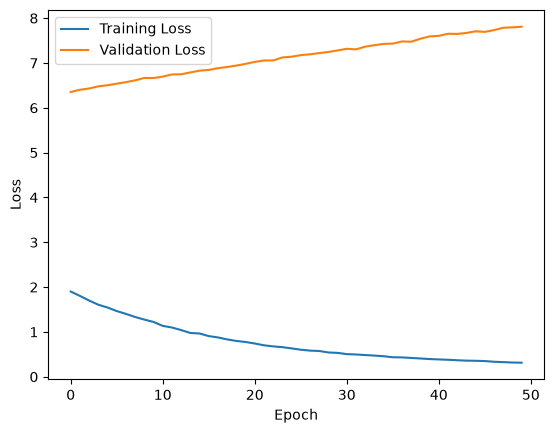

In [38]:
plt.plot(lstm_history.history["loss"])
plt.plot(lstm_history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [39]:
gru_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=EMBEDDING_DIM
    ),

    GRU(RNN_UNITS),

    Dropout(0.2),

    Dense(
        total_words,
        activation="softmax"
    )
])

In [42]:
# Save the trained LSTM artifacts used by the Streamlit app.
os.makedirs("models", exist_ok=True)
lstm_model.save("models/next_word_lstm.keras")
with open("models/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)


def predict_next_words(seed_text, model=lstm_model, top_k=5):
    """Return the most likely next words for a seed phrase."""
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    if not token_list:
        return []

    model_input = pad_sequences(
        [token_list],
        maxlen=max_sequence_length - 1,
        padding="pre"
    )
    probabilities = model.predict(model_input, verbose=0)[0]
    top_indices = np.argsort(probabilities)[-top_k:][::-1]
    index_word = {index: word for word, index in tokenizer.word_index.items()}

    return [
        (index_word[index], float(probabilities[index]))
        for index in top_indices
        if index in index_word
    ]


print(predict_next_words("a"))

[('small', 0.10054375976324081), ('strong', 0.08318133652210236), ('machine', 0.07403457909822464), ('larger', 0.07022777944803238), ('project', 0.04046532139182091)]
